# 4.43 Mesh and Solve the 10 × 10 Processor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/docs%2Ftut%2F4-Analysis%2F4.43-Mesh-and-solve-the-10x10-processor.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=docs%2Ftut%2F4-Analysis%2F4.43-Mesh-and-solve-the-10x10-processor.ipynb)

> 💡 **What you need.** gmsh, scikit-fem and SciPy: `pip install "quantum-metal[skfem]" pymetis` (pymetis is optional; it makes the sparse factorizations several times faster and lighter). About 4 minutes and 8 GB of memory. Third of five notebooks reproducing Molavi *et al.* [1].

> 🧭 **Other simulation pathways.** This notebook uses the open-source gmsh + scikit-fem solver. The same quantities can come from Ansys HFSS / Q3D (tutorials 4.01–4.23) or, for capacitance, from the open-source ElmerFEM path for capacitance (tutorial 4.19); AWS Palace is available through SQDMetal, with a native integration in progress. [Simulation pathways](https://qiskit-community.github.io/qiskit-metal/simulation-pathways.html) summarizes what each solver computes, how to install it, and which tutorials use it.

The paper simulates its 10 × 10 transmon array in Ansys HFSS. This notebook does the same calculation with open-source tools, end to end: the device is drawn in **Quantum Metal**, meshed with **gmsh**, and its package mode found with a finite-element Maxwell solver assembled with **scikit-fem** and solved with **SciPy**. The solver lives in [`docs/tut/resources/package_modes/package_modes.py`](../resources/package_modes/package_modes.py) and is written to be read.

**What you'll learn**

- how to describe the paper's device as a Quantum Metal design and hand its geometry to gmsh;
- how to seed a mesh for a problem that spans five decades of length — a 0.2 mm junction gap in a 30 mm box;
- how a Maxwell eigenproblem is set up on edge elements: what the unknowns mean, how metal and symmetry planes enter, and why a junction is just one extra term;
- how to look inside a 3D solution — slices, zooms, line cuts — and check it against the analytic mode of notebook 4.41;
- how to get each qubit's capacitance, charge distribution and dipole moment from electrostatics on the same geometry.

In [1]:
# In Colab, uncomment to install the dependencies of the whole series.
# !pip install -q "quantum-metal[skfem]" pymetis

In [2]:
import sys
import urllib.request
from pathlib import Path

# The solver code shared by tutorials 4.41-4.45 lives in docs/tut/resources/package_modes/.
RES = Path("../resources/package_modes")
if not (
    RES / "package_modes.py"
).exists():  # e.g. in Colab: fetch it next to the notebook
    RES = Path("package_modes")
    RES.mkdir(exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/qiskit-community/qiskit-metal/main/"
        "docs/tut/resources/package_modes/package_modes.py",
        RES / "package_modes.py",
    )
sys.path.insert(0, str(RES))

import package_modes as pm

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection

import qiskit_metal as qm

warnings.filterwarnings("ignore", category=FutureWarning)

# Mesh seeding (mm): fine along the paddle edges and junctions, coarse in the bulk
# where the package mode varies over centimeters. Add h_junction=0.05 to seed a
# small sphere around each junction more finely (slower, a few percent closer to converged).
MESH = dict(h_metal=0.1, h_max=1.0)

## 1. The design in Quantum Metal

`pm.build_design()` builds the validation device of the paper's Fig. 4 as a `MultiPlanar` design — the layer-stack design that Quantum Metal's meshing renderers read. The chip is 30 × 30 mm with no ground plane. The layer stack holds zero-thickness metal on a 0.5 mm silicon substrate, and the sample-holder variables put the package lid 2.5 mm above the chip.

Each qubit is a `TwoPadTransmon`: a nine-line `QComponent`, defined in the resource module, that draws two paddles and a junction line across the gap. It is the bare transmon of the paper — a `TransmonPocket` would also cut a pocket into a ground plane this chip does not have.

100 qubits, chip 30.0mm x 30.0mm
{'pos_x': '1.5mm', 'pos_y': '1.5mm', 'orientation': '0', 'chip': 'main', 'layer': '1', 'connection_pads': {}, 'pad_width': '0.5mm', 'pad_height': '1.0mm', 'pad_gap': '0.2mm', 'jj_width': '20um', 'gds_cell_name': 'my_other_junction'}


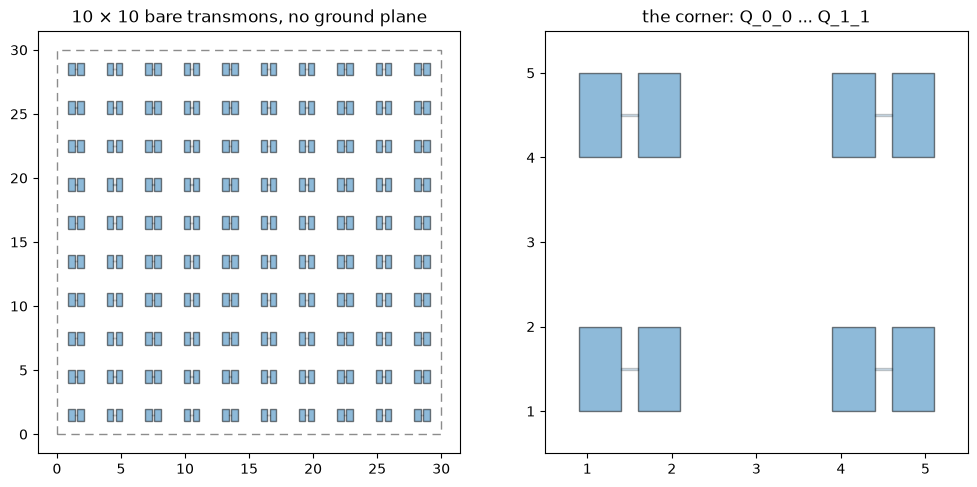

In [3]:
design = pm.build_design()
print(
    f"{len(design.components)} qubits, chip {design.chips.main.size.size_x} x {design.chips.main.size.size_y}"
)
print(design.components["Q_0_0"].options)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
qm.view(design, ax=ax[0], title="10 × 10 bare transmons, no ground plane")
qm.view(
    design,
    ax=ax[1],
    components=[f"Q_{i}_{j}" for i in range(2) for j in range(2)],
    title="the corner: Q_0_0 ... Q_1_1",
)
ax[1].set(xlim=(0.5, 5.5), ylim=(0.5, 5.5))
plt.show()

## 2. From design to package

`pm.package_from_design` reads back what a solver needs: the box (from the chip outline, layer stack and sample-holder variables), every paddle polygon, and every junction line. Here it is in 3D — the box, the silicon slab, and the 200 paddles on the silicon surface.

box 30.0 x 30.0 x 3.0 mm, silicon 0.5 mm, 200 paddles, 100 junctions


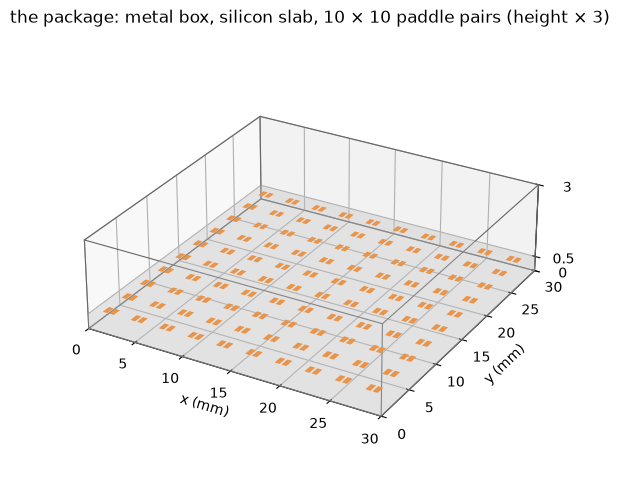

In [4]:
package = pm.package_from_design(design)
print(
    f"box {package.Lx} x {package.Ly} x {package.Lz} mm, silicon {package.t} mm,"
    f" {len(package.metals)} paddles, {len(package.junctions)} junctions"
)


fig = plt.figure(figsize=(9, 6))
ax3 = fig.add_subplot(projection="3d")
pm.plot_package_3d(ax3, package)
ax3.set_title("the package: metal box, silicon slab, 10 × 10 paddle pairs (height × 3)")
plt.show()

## 3. Meshing: five decades of length

The mode fills a 30 mm box; the physics of each coupling lives in a 0.2 mm junction gap. `pm.mesh_package` builds the geometry in gmsh's OpenCASCADE kernel — two boxes for the silicon and the vacuum, the paddles as zero-thickness surfaces on the silicon, each junction as a line — and *fragments* them so the mesh conforms to every interface. The junction lines become chains of mesh edges: the voltage across a junction is a sum over them, and notebook 4.45 puts lumped inductors on them.

The mesh size is seeded where the physics needs it (`MESH` above):

| where | size | why |
|---|---|---|
| paddle edges and junction lines | `h_metal` = 0.1 mm | the qubit's charge crowds onto the edges, and the coupling is read across the gap |
| the bulk | `h_max` = 1 mm | the package mode varies over centimeters |
| *optional:* a small sphere around each junction | `h_junction` | the field is strongest in the gap; seeding it finely is the cheapest way to converge the junction voltages |

In [5]:
mesh = pm.mesh_package(package, region="full", **MESH)
print(mesh.summary())

full package: 435,564 tetrahedra, 80,891 nodes, 200 paddles, 100 junctions (meshed in 7.4 s)


From the whole chip down to a single junction gap, the triangles on the silicon surface:

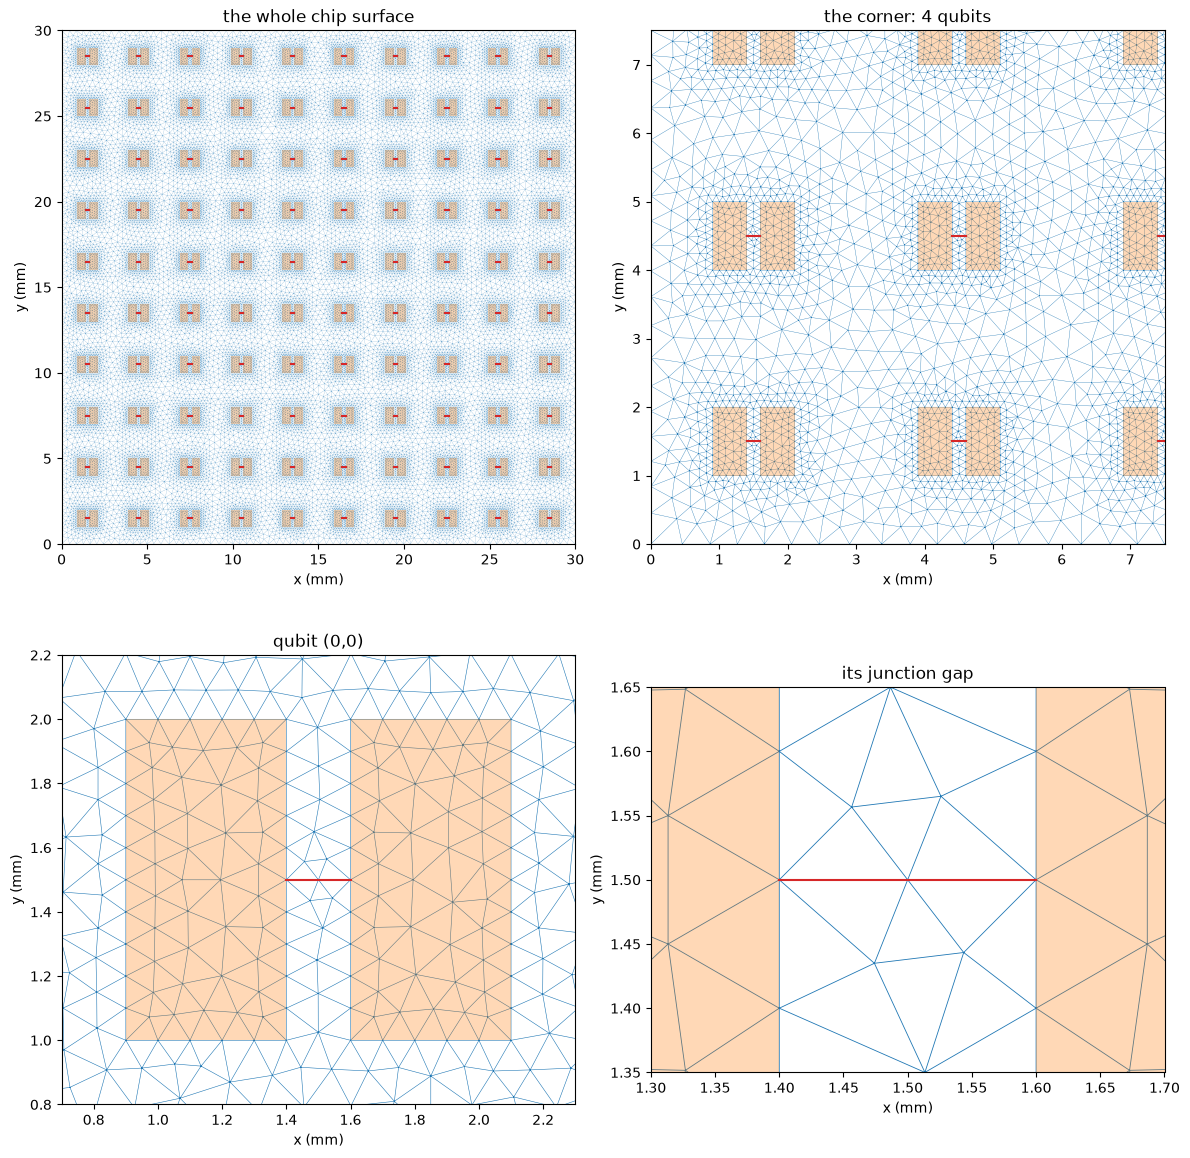

In [6]:
tri = mesh.triangles_in_plane(package.t)
xy = mesh.p[:2]
views = [
    ((0, 30, 0, 30), "the whole chip surface", 0.1),
    ((0, 7.5, 0, 7.5), "the corner: 4 qubits", 0.25),
    ((0.7, 2.3, 0.8, 2.2), "qubit (0,0)", 0.4),
    ((1.3, 1.7, 1.35, 1.65), "its junction gap", 0.6),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for a, ((x0, x1, y0, y1), title, lw) in zip(axes.flat, views):
    a.triplot(xy[0], xy[1], tri, lw=lw, color="tab:blue")
    for poly in package.metals.values():
        a.fill(poly[:, 0], poly[:, 1], color="tab:orange", alpha=0.3, lw=0)
    for a_, b_ in package.junctions.values():
        a.plot([a_[0], b_[0]], [a_[1], b_[1]], color="tab:red", lw=1.5)
    a.set(
        xlim=(x0, x1),
        ylim=(y0, y1),
        aspect="equal",
        xlabel="x (mm)",
        ylabel="y (mm)",
        title=title,
    )
plt.tight_layout()
plt.show()

And through the package: `mesh.slice` cuts every tetrahedron with a plane. A vertical cut through the first row of qubits shows the silicon and the vacuum, the refinement hugging the paddles on the silicon surface, and the coarse elements that carry the package mode above.

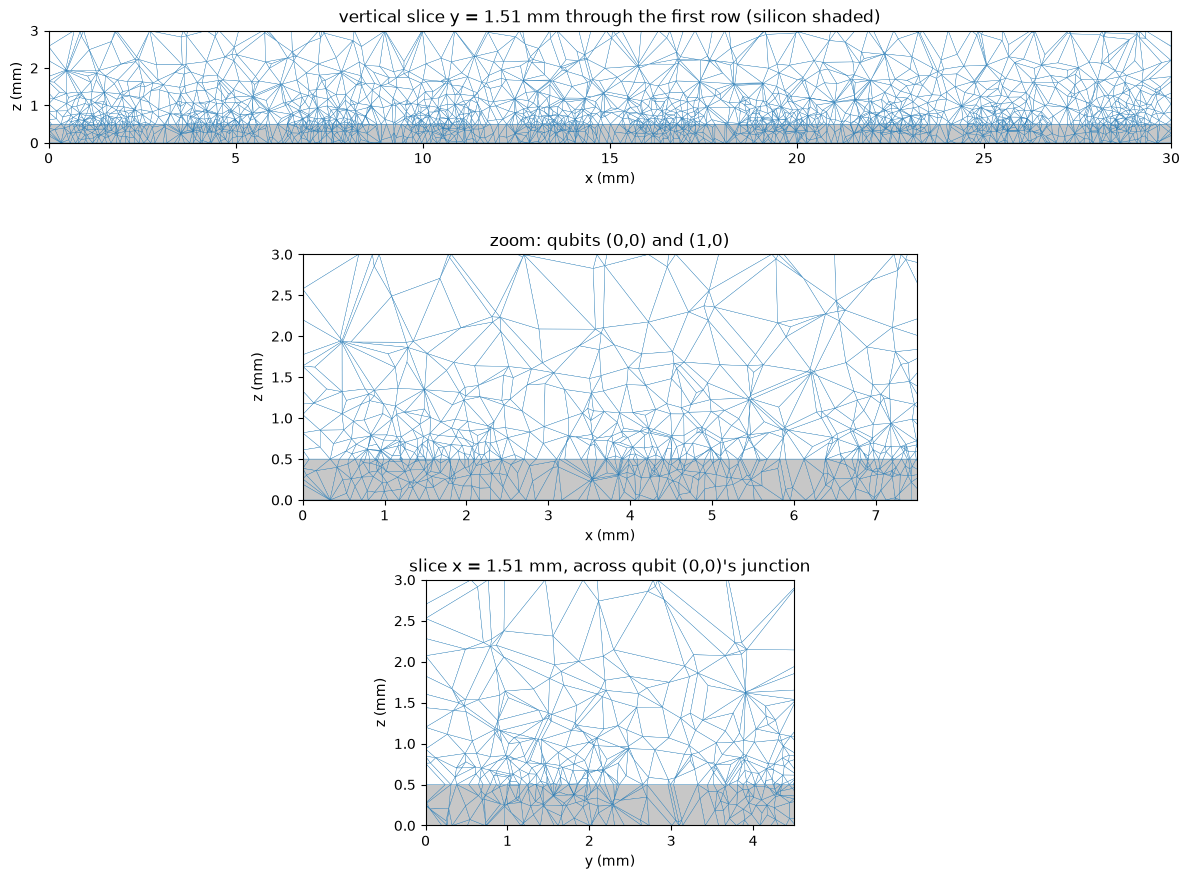

In [7]:
def draw_slice(ax, polys, mats, lim):
    colors = np.where(mats[:, None] == 1, [[0.78, 0.78, 0.78, 1]], [[1, 1, 1, 1]])
    ax.add_collection(
        PolyCollection(polys, facecolors=colors, edgecolors="tab:blue", linewidths=0.25)
    )
    ax.set(xlim=lim[:2], ylim=lim[2:], aspect="equal")


polys_xz, mats_xz = mesh.slice(
    axis=1, value=1.51
)  # through row 0, along x (just off the junction line)
polys_yz, mats_yz = mesh.slice(
    axis=0, value=1.51
)  # through qubit (0,0)'s junction, along y
fig, ax = plt.subplots(
    3, 1, figsize=(12, 9), gridspec_kw=dict(height_ratios=[1, 1.4, 1.4])
)
draw_slice(ax[0], polys_xz, mats_xz, (0, 30, 0, 3))
ax[0].set(
    title="vertical slice y = 1.51 mm through the first row (silicon shaded)",
    xlabel="x (mm)",
    ylabel="z (mm)",
)
draw_slice(ax[1], polys_xz, mats_xz, (0, 7.5, 0, 3))
ax[1].set(title="zoom: qubits (0,0) and (1,0)", xlabel="x (mm)", ylabel="z (mm)")
draw_slice(ax[2], polys_yz, mats_yz, (0, 4.5, 0, 3))
ax[2].set(
    title="slice x = 1.51 mm, across qubit (0,0)'s junction",
    xlabel="y (mm)",
    ylabel="z (mm)",
)
plt.tight_layout()
plt.show()

## 4. The Maxwell eigenproblem on edge elements

A package mode solves $\nabla\times\nabla\times\mathbf E = k_0^2\varepsilon_r\mathbf E$ with no tangential $\mathbf E$ on metal. In the weak form used by finite elements,

$$\int \nabla\times\mathbf E\cdot\nabla\times\mathbf F\, dV \;=\; k_0^2 \int \varepsilon_r\,\mathbf E\cdot\mathbf F\, dV \qquad \text{for every test field } \mathbf F,$$

which after discretization is a generalized eigenproblem $K u = k_0^2 M u$. Its unknowns live on the **edges** of the mesh: lowest-order Nédélec elements take as degree of freedom the line integral of $\mathbf E$ along each edge, in volts. That choice makes the physics transparent:

- **metal** — the box walls and every paddle — forces tangential $\mathbf E = 0$, so the edges lying on metal simply drop out;
- a **voltage** across any path of edges — a junction gap — is a signed sum of unknowns;
- a **lumped inductor** $L$ across a junction adds its energy $V^2/2L$ as a rank-one term $(\mu_0/L)\,c\,c^T$ to $K$, where $c$ picks out the junction edges. That is all notebook 4.45 needs for three of the four methods.

`pm.MaxwellFEM` assembles $K$ and $M$ with scikit-fem and removes the metal edges. `eigenmodes` factors $K - \sigma M$ once, with a nested-dissection ordering from METIS, and lets SciPy's ARPACK find the modes nearest the shift $\sigma$. With all junctions open, the qubit modes sit at zero frequency — they are static charge configurations of isolated paddles — and only the package modes remain near 6.5 GHz, as the paper notes for its induced-EMF method.

Three solves build up the device the way the paper describes it (Sec. III): the empty box, then the silicon slab, then the paddles. The first two need no fine mesh.

In [8]:
results = {}
for label, kw in (
    ("empty box", dict(pads=False, substrate=False)),
    ("with silicon", dict(pads=False)),
):
    m = pm.mesh_package(package, region="full", h_max=0.8, **kw)
    results[label] = pm.MaxwellFEM(m).eigenmodes(6.5e9)[0].f

start = time.time()
fem = pm.MaxwellFEM(mesh)
(mode,) = fem.eigenmodes(6.5e9)
results["with 100 paddles"] = mode.f
print(
    f"full box: {fem.n_dofs:,} unknowns, assembled and solved in {time.time() - start:.0f} s\n"
)

P = pm.PAPER
paper = {
    "empty box": P["f_empty"],
    "with silicon": P["f_si"],
    "with 100 paddles": P["f_pads"],
}
analytic = {
    "empty box": pm.lsm_mode(1, 1, eps_r=1 + 1e-9).f,
    "with silicon": pm.lsm_mode(1, 1).f,
}
print(f"{'':>18} {'FEM (GHz)':>10} {'analytic':>9} {'paper':>7}")
for k, f in results.items():
    a = f"{analytic[k] / 1e9:9.3f}" if k in analytic else " " * 9
    print(f"{k:>18} {f / 1e9:10.3f} {a} {paper[k] / 1e9:7.2f}")

full box: 452,925 unknowns, assembled and solved in 42 s

                    FEM (GHz)  analytic   paper
         empty box      7.065     7.066    7.07
      with silicon      6.487     6.493    6.49
  with 100 paddles      6.486              6.48


The empty box and the slab agree with the analytic LSM mode to about 0.1%. The paddles lower the mode by only a few MHz. A flat sheet of metal forbids only a *tangential* electric field, and at the chip surface the package field is almost entirely vertical — normal to the paddles — so they barely disturb it. The paper reports the same small shift (6.49 → 6.48 GHz, rounded).

## 5. Inside the solution

`mode.field(points)` evaluates the finite-element field anywhere, in V/m for 1 J in the mode. First the big picture: the vertical field on a horizontal plane in the vacuum, and on a vertical slice through the middle of the box.

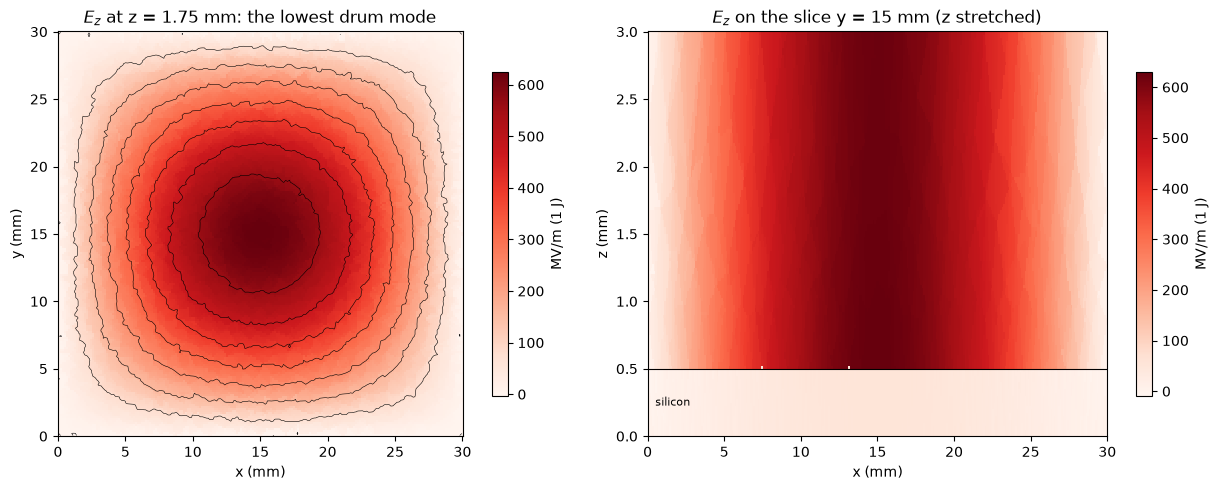

In [9]:
gx, gy = np.meshgrid(np.linspace(0.05, 29.95, 200), np.linspace(0.05, 29.95, 200))
top = mode.field(np.vstack([gx.ravel(), gy.ravel(), np.full(gx.size, 1.75)]))[
    2
].reshape(gx.shape)
sx, sz = np.meshgrid(np.linspace(0.05, 29.95, 300), np.linspace(0.01, 2.99, 120))
side = mode.field(np.vstack([sx.ravel(), np.full(sx.size, 15.0), sz.ravel()]))[
    2
].reshape(sx.shape)

fig = plt.figure(figsize=(13, 5))
a0 = fig.add_subplot(1, 2, 1)
im = a0.pcolormesh(gx, gy, top / 1e6, cmap="Reds", shading="auto")
a0.contour(gx, gy, top / 1e6, levels=8, colors="k", linewidths=0.4)
a0.set(
    aspect="equal",
    xlabel="x (mm)",
    ylabel="y (mm)",
    title="$E_z$ at z = 1.75 mm: the lowest drum mode",
)
plt.colorbar(im, ax=a0, shrink=0.8, label="MV/m (1 J)")
a1 = fig.add_subplot(1, 2, 2)
im = a1.pcolormesh(sx, sz, side / 1e6, cmap="Reds", shading="auto")
a1.axhline(package.t, color="k", lw=0.8)
a1.text(0.5, package.t / 2, "silicon", va="center", fontsize=8)
a1.set(
    xlabel="x (mm)", ylabel="z (mm)", title="$E_z$ on the slice y = 15 mm (z stretched)"
)
plt.colorbar(im, ax=a1, shrink=0.8, label="MV/m (1 J)")
plt.tight_layout()
plt.show()

Normalized to 1 J like the analytic mode of notebook 4.41, the two can be compared directly — through the thickness at the center of the box (the paper's Fig. 11), and along the line between rows 4 and 5, where the in-plane field $E_x$ at the silicon surface is the one the qubits feel.

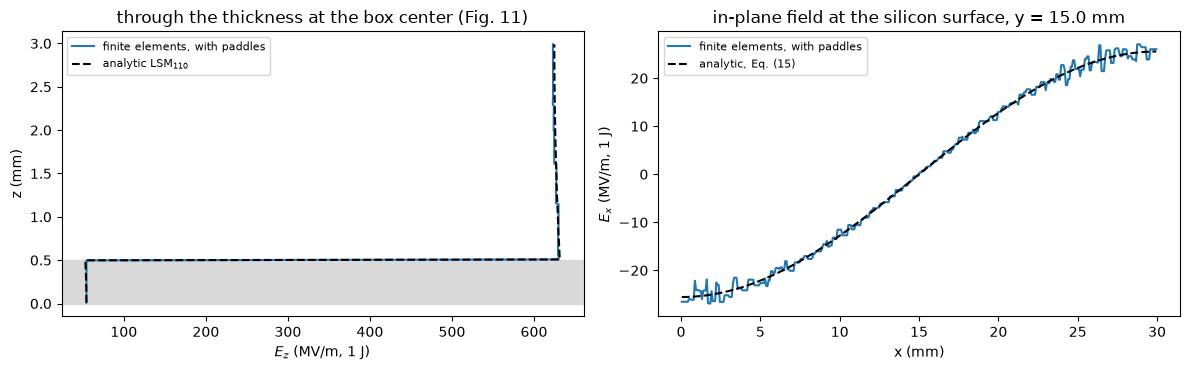

In [10]:
lsm = pm.lsm_mode(1, 1)
z = np.linspace(0.01, package.Lz - 0.01, 300)
Ez_fem = mode.field(np.vstack([np.full_like(z, 15.0), np.full_like(z, 15.0), z]))[2]

x = np.linspace(0.05, 29.95, 400)
y_line = 15.0  # halfway between rows 4 and 5, clear of the paddles
Ex_fem = mode.field(
    np.vstack([x, np.full_like(x, y_line), np.full_like(x, package.t + 1e-6)])
)[0]
Ex_lsm = lsm.Ex_surface(x * 1e-3, y_line * 1e-3)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(Ez_fem / 1e6, z, label="finite elements, with paddles")
ax[0].plot(lsm.Ez(z * 1e-3) / 1e6, z, "k--", label="analytic LSM$_{110}$")
ax[0].axhspan(0, package.t, color="0.85", zorder=0)
ax[0].set(
    xlabel="$E_z$ (MV/m, 1 J)",
    ylabel="z (mm)",
    title="through the thickness at the box center (Fig. 11)",
)
ax[0].legend(fontsize=8)
ax[1].plot(x, Ex_fem / 1e6, label="finite elements, with paddles")
ax[1].plot(x, Ex_lsm / 1e6, "k--", label="analytic, Eq. (15)")
ax[1].set(
    xlabel="x (mm)",
    ylabel="$E_x$ (MV/m, 1 J)",
    title=f"in-plane field at the silicon surface, y = {y_line} mm",
)
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

The vertical profile matches Fig. 11, and along the surface the finite-element $E_x$ follows the analytic cosine of Eq. (15); its jitter is the element-to-element jump of lowest-order edge elements, which represent the field as piecewise linear. Mapped over the whole surface, each qubit shows up as a dipole-shaped disturbance on top of the package field: the paddles pin the tangential field to zero on themselves and squeeze it into the gaps and around the outer edges. Zooming in on one qubit shows where the in-plane field goes.

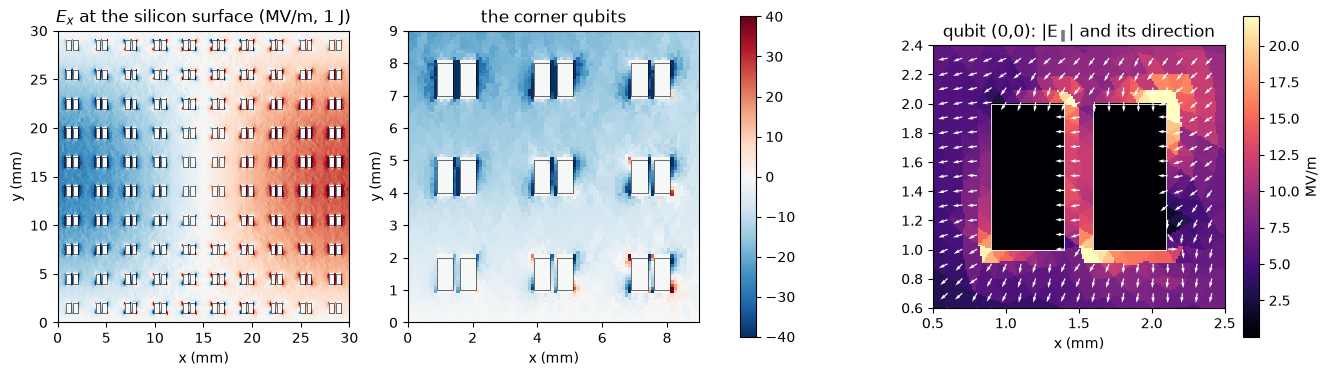

In [11]:
gx, gy = np.meshgrid(np.linspace(0.05, 29.95, 300), np.linspace(0.05, 29.95, 300))
Ex = (
    mode.field(np.vstack([gx.ravel(), gy.ravel(), np.full(gx.size, package.t + 1e-6)]))[
        0
    ].reshape(gx.shape)
    / 1e6
)
zx, zy = np.meshgrid(np.linspace(0.5, 2.5, 160), np.linspace(0.6, 2.4, 144))
Ez_ = mode.field(
    np.vstack([zx.ravel(), zy.ravel(), np.full(zx.size, package.t + 1e-6)])
)
Exz, Eyz = Ez_[0].reshape(zx.shape) / 1e6, Ez_[1].reshape(zx.shape) / 1e6

fig, ax = plt.subplots(1, 3, figsize=(16, 5.2))
lim = 40
for a, (x0, x1, y0, y1), title in (
    (ax[0], (0, 30, 0, 30), "$E_x$ at the silicon surface (MV/m, 1 J)"),
    (ax[1], (0, 9, 0, 9), "the corner qubits"),
):
    im = a.pcolormesh(gx, gy, Ex, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="auto")
    for poly in package.metals.values():
        a.fill(poly[:, 0], poly[:, 1], facecolor="none", edgecolor="k", lw=0.4)
    a.set(
        xlim=(x0, x1),
        ylim=(y0, y1),
        aspect="equal",
        xlabel="x (mm)",
        ylabel="y (mm)",
        title=title,
    )
mag = np.hypot(Exz, Eyz)
im2 = ax[2].pcolormesh(
    zx, zy, mag, cmap="magma", vmax=np.percentile(mag, 99), shading="auto"
)
step = 8
norm_ = np.hypot(Exz, Eyz)[::step, ::step] + 1e-12
norm_[norm_ < 0.05 * norm_.max()] = (
    np.nan
)  # no arrows inside the metal, where the field vanishes
ax[2].quiver(
    zx[::step, ::step],
    zy[::step, ::step],
    Exz[::step, ::step] / norm_,
    Eyz[::step, ::step] / norm_,
    color="w",
    scale=30,
    width=0.004,
)
for poly in package.metals.values():
    ax[2].fill(poly[:, 0], poly[:, 1], facecolor="none", edgecolor="w", lw=0.6)
ax[2].set(
    xlim=(0.5, 2.5),
    ylim=(0.6, 2.4),
    aspect="equal",
    xlabel="x (mm)",
    title="qubit (0,0): |E$_\\parallel$| and its direction",
)
plt.colorbar(im, ax=ax[:2], shrink=0.8)
plt.colorbar(im2, ax=ax[2], shrink=0.8, label="MV/m")
plt.show()

## 6. Qubit capacitance, charge and dipole moment

The induced-EMF method (notebook 4.44) turns the voltage across each open junction into a coupling, and for that it needs one more number per qubit: the capacitance seen across its junction, $C_n + C_c$ in the paper's notation. That is an electrostatics problem on the same kind of mesh. `pm.Electrostatics` solves $\nabla\cdot(\varepsilon\nabla\phi) = 0$ with second-order Lagrange elements. Each paddle is a perfect conductor, so all its nodes collapse to a single unknown, and the capacitance matrix of all paddles is the Schur complement of the stiffness matrix onto those unknowns — one factorization for all of them.

The capacitance of a qubit is a local property: the nearest walls and neighbors are millimeters away. So a **quarter** of the package, with its 25 qubits, is enough. The cut faces are left as symmetry planes — the same trick notebook 4.44 uses to converge the couplings.

In [12]:
quarter = pm.mesh_package(package, region="quarter", h_metal=0.07, h_max=0.7)
print(quarter.summary())
start = time.time()
es = pm.Electrostatics(quarter)
print(f"capacitance matrix of {len(es.names)} paddles in {time.time() - start:.0f} s")

Cq = np.full((5, 5), np.nan)
for i in range(5):
    for j in range(5):
        Cq[j, i] = es.port_capacitance(f"Q_{i}_{j}.pad_left", f"Q_{i}_{j}.pad_right")
print(
    f"capacitance across the junction: {Cq.min() * 1e15:.1f} to {Cq.max() * 1e15:.1f} fF"
    f"  (paper, qubit (0,0) from the impedance fit: {P['zfit_q00']['C_n'] * 1e15:.1f} fF)"
)
a, b = es.index("Q_0_0.pad_left"), es.index("Q_0_0.pad_right")
C_gap, C_ground = -es.C[a, b], es.C[a].sum()
print(
    f"qubit (0,0): {C_gap * 1e15:.1f} fF across the gap, {C_ground * 1e15:.1f} fF from each paddle to ground;"
    f" in series the ground path adds {C_ground / 2 * 1e15:.1f} fF"
)

quarter package: 300,532 tetrahedra, 53,821 nodes, 50 paddles, 25 junctions (meshed in 2.3 s)


capacitance matrix of 50 paddles in 72 s
capacitance across the junction: 173.4 to 174.1 fF  (paper, qubit (0,0) from the impedance fit: 173.8 fF)
qubit (0,0): 47.8 fF across the gap, 252.2 fF from each paddle to ground; in series the ground path adds 126.1 fF


About 174 fF everywhere, varying by a few tenths of a percent between the corner and the center — the value the paper extracts for qubit (0,0) from its impedance fit, found here directly. The Maxwell matrix splits it into the capacitance across the gap and a path through the grounded package: each paddle to the floor, mostly through the silicon, the two in series.

Where does the charge sit, and where do its field lines go? For 1 J in the qubit mode of qubit (0,0): the nodal charges on the paddles, their distribution along $x$, and the potential on a vertical slice through the qubit.

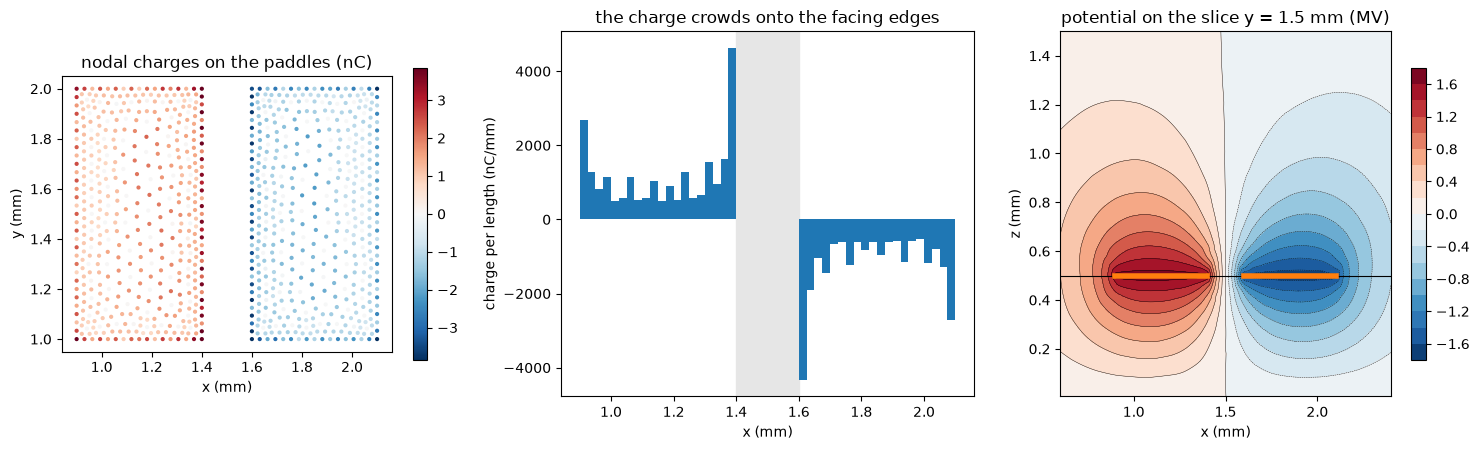

|p_x| = 3.792e-10 C m for 1 J   (paper: 3.41e-10 C m from the HFSS surface current)
dipole length |p_x| / sqrt(2 C) = 0.64 mm   (paper: 0.58 mm; paddle centers are 0.70 mm apart)


In [13]:
loc, q = es.charges("Q_0_0.pad_left", "Q_0_0.pad_right")
near = (np.abs(loc[0] - 1.5) < 0.7) & (np.abs(loc[1] - 1.5) < 0.6)
bins = np.linspace(0.9, 2.1, 49)
line_density, _ = np.histogram(loc[0, near], bins, weights=q[near])
px_, pz_ = np.meshgrid(np.linspace(0.6, 2.4, 181), np.linspace(0.005, 1.5, 120))
phi = es.potential(
    "Q_0_0.pad_left",
    "Q_0_0.pad_right",
    np.vstack([px_.ravel(), np.full(px_.size, 1.5), pz_.ravel()]),
)

fig = plt.figure(figsize=(15, 4.6))
a0 = fig.add_subplot(1, 3, 1)
lim = np.percentile(np.abs(q[near]), 99) * 1e9
sc = a0.scatter(
    loc[0, near], loc[1, near], c=q[near] * 1e9, cmap="RdBu_r", vmin=-lim, vmax=lim, s=4
)
a0.set(
    aspect="equal",
    xlabel="x (mm)",
    ylabel="y (mm)",
    title="nodal charges on the paddles (nC)",
)
plt.colorbar(sc, ax=a0, shrink=0.8)
a1 = fig.add_subplot(1, 3, 2)
a1.bar(
    bins[:-1],
    line_density / np.diff(bins) * 1e9,
    width=np.diff(bins),
    align="edge",
    color="tab:blue",
)
a1.axvspan(1.4, 1.6, color="0.9", zorder=0)
a1.set(
    xlabel="x (mm)",
    ylabel="charge per length (nC/mm)",
    title="the charge crowds onto the facing edges",
)
a2 = fig.add_subplot(1, 3, 3)
im = a2.contourf(px_, pz_, phi.reshape(px_.shape) / 1e6, levels=21, cmap="RdBu_r")
a2.contour(px_, pz_, phi.reshape(px_.shape), levels=21, colors="k", linewidths=0.3)
a2.axhline(package.t, color="k", lw=0.8)
for xa, xb in ((0.9, 1.4), (1.6, 2.1)):
    a2.plot([xa, xb], [package.t, package.t], color="tab:orange", lw=4)
a2.set(xlabel="x (mm)", ylabel="z (mm)", title="potential on the slice y = 1.5 mm (MV)")
plt.colorbar(im, ax=a2, shrink=0.8)
plt.tight_layout()
plt.show()

px = es.dipole("Q_0_0.pad_left", "Q_0_0.pad_right")[0]
length = abs(px) / np.sqrt(2 * Cq[0, 0])
print(
    f"|p_x| = {abs(px):.3e} C m for 1 J   (paper: {P['px']:.2e} C m from the HFSS surface current)"
)
print(
    f"dipole length |p_x| / sqrt(2 C) = {length * 1e3:.2f} mm   (paper: {P['dipole_length'] * 1e3:.2f} mm;"
    f" paddle centers are 0.70 mm apart)"
)

The charge crowds onto the inner edges, so the dipole length is shorter than the 0.70 mm between paddle centers, as the paper argues. The potential shows the two paths of the capacitance: straight across the gap, and down through the silicon to the floor. Our electrostatic dipole moment is about 10% larger than the paper's, which comes from a surface-current integral in HFSS; ours does not change with mesh refinement (0.64 mm at 0.1, 0.07 and 0.05 mm paddle-edge elements). Plugged into the dipole estimate of notebook 4.41, it gives:

In [14]:
kC, A_dip = pm.dipole_coupling(abs(px), lsm)
print(
    f"dipole estimate A/2pi = {A_dip / 1e6:.1f} MHz with this p_x "
    f"(paper: {P['A_110_dipole'] / 1e6:.1f} MHz with its p_x; full-wave fit {P['A_110'] / 1e6:.1f} MHz)"
)

dipole estimate A/2pi = 15.7 MHz with this p_x (paper: 14.2 MHz with its p_x; full-wave fit 15.6 MHz)


## Summary

- A Quantum Metal design of the paper's processor, meshed with gmsh and solved with an open-source finite-element Maxwell solver in about a minute.
- Package mode: 7.07 GHz empty, 6.49 GHz with silicon, a few MHz lower with the paddles, as in the paper; the fields match the analytic LSM mode, and each qubit shows up as a dipole-shaped disturbance at the silicon surface.
- Qubit capacitance ≈ 174 fF, matching the paper's fitted value; dipole length 0.64 mm.

## Where to go next

- **4.44 Every coupling from one eigenmode** — the voltage this mode induces across each of the 100 open junctions, turned into the coupling map of the paper's Figs. 6, 8 and 9.
- Change the package: `pm.build_design(Lz=4)` raises the lid, `pm.build_design(t=0.25)` thins the slab — rebuild, re-mesh and re-solve with the same cells.
- Mesh seeding: add `h_junction=0.05` to `MESH`, or halve `h_metal`, and compare the frequency and the fields — a first convergence check.

## References

1. R. Molavi, E. Forati, Y. Zhang, A. R. Klots, J. Atalaya, B. W. Langley, D. A. Timucin, M. Nazari, G. Khan, Z. K. Minev, A. N. Korotkov, M. H. Devoret, "Extracting electromagnetic bare mode couplings in large superconducting quantum processors," [arXiv:2609.22442](https://arxiv.org/abs/2609.22442) (2026).
2. Z. K. Minev, Z. Leghtas, S. O. Mundhada, L. Christakis, I. M. Pop, M. H. Devoret, "Energy-participation quantization of Josephson circuits," *npj Quantum Inf.* **7**, 131 (2021). [doi:10.1038/s41534-021-00461-8](https://doi.org/10.1038/s41534-021-00461-8)
3. C. A. Balanis, *Advanced Engineering Electromagnetics*, 2nd ed. (Wiley, 2012) — LSM modes of a partially filled waveguide.
4. C. Geuzaine, J.-F. Remacle, "Gmsh: A 3-D finite element mesh generator with built-in pre- and post-processing facilities," *Int. J. Numer. Methods Eng.* **79**, 1309–1331 (2009). [doi:10.1002/nme.2579](https://doi.org/10.1002/nme.2579)
5. T. Gustafsson, G. D. McBain, "scikit-fem: A Python package for finite element assembly," *J. Open Source Softw.* **5**, 2369 (2020). [doi:10.21105/joss.02369](https://doi.org/10.21105/joss.02369)